In [9]:
# --- 1. CORE DATA & VIZ ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
%matplotlib inline

# --- 2. STATSMODELS (Statistical Inference & Formulas) ---
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm
from statsmodels.nonparametric.smoothers_lowess import lowess

# --- 3. SKLEARN: PREPROCESSING & DATA PIPELINES ---
from sklearn.model_selection import (
    train_test_split, LeaveOneOut, KFold, 
    cross_val_score, GridSearchCV, RandomizedSearchCV
)
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, PolynomialFeatures, OneHotEncoder
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# --- 4. SKLEARN: LINEAR MODELS (Chapter 3, 4, & 6) ---
from sklearn.linear_model import (
    LinearRegression, LogisticRegression, 
    Ridge, Lasso, ElasticNet, RidgeCV, LassoCV
)

# --- 5. SKLEARN: MODEL SELECTION & DIMENSIONALITY REDUCTION (Chapter 6) ---
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression

# --- 6. SKLEARN: TREE-BASED MODELS & ENSEMBLES (Chapter 8) ---
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier,
    GradientBoostingRegressor, GradientBoostingClassifier,
    BaggingRegressor, AdaBoostRegressor
)

# --- 7. SKLEARN: SUPPORT VECTOR MACHINES (Chapter 9) ---
from sklearn.svm import SVC, SVR

# --- 8. SKLEARN: NEAREST NEIGHBORS & CLUSTERING (Chapter 4 & 12) ---
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.cluster import KMeans, AgglomerativeClustering

# --- 9. SKLEARN: EVALUATION METRICS ---
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error,
    accuracy_score, confusion_matrix, classification_report, 
    roc_curve, auc, roc_auc_score, silhouette_score
)

# --- 10. UTILS & RESAMPLING ---
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')
from patsy import (
    dmatrix, bs
)

## Tree-Based Models (TBM)

In [22]:
df = pd.read_csv("Heart.csv")
df

,Unnamed: 0,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
0,1,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
1,2,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
2,3,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
3,4,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
4,5,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,299,45,1,typical,110,264,0,0,132,0,1.2,2,0.0,reversable,Yes
299,300,68,1,asymptomatic,144,193,1,0,141,0,3.4,2,2.0,reversable,Yes
300,301,57,1,asymptomatic,130,131,0,0,115,1,1.2,2,1.0,reversable,Yes
301,302,57,0,nontypical,130,236,0,2,174,0,0.0,2,1.0,normal,Yes


In [25]:
df["AHD"].unique()

array(['No', 'Yes'], dtype=object)

In [26]:
# Convert target to binary
df["AHD"] = df["AHD"].map({"No": 0, "Yes": 1})

#sns.histplot(df["AHD"])
#plt.title("Presence of Heart Desease")

In [32]:
# Separate features and target
X = df.drop(columns=["AHD"])
X = pd.get_dummies(X, drop_first=True)

y = df["AHD"]

In [33]:
X.head()

,Unnamed: 0,Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,ChestPain_nonanginal,ChestPain_nontypical,ChestPain_typical,Thal_normal,Thal_reversable
0,1,63,1,145,233,1,2,150,0,2.3,3,0.0,False,False,True,False,False
1,2,67,1,160,286,0,2,108,1,1.5,2,3.0,False,False,False,True,False
2,3,67,1,120,229,0,2,129,1,2.6,2,2.0,False,False,False,False,True
3,4,37,1,130,250,0,0,187,0,3.5,3,0.0,True,False,False,True,False
4,5,41,0,130,204,0,2,172,0,1.4,1,0.0,False,True,False,True,False


## Classification Trees

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y)

In [65]:
tree = DecisionTreeClassifier(
    criterion="gini",
    max_leaf_nodes=6,   # consistent with cross-validation result
    random_state=42
)

tree.fit(X_train, y_train)

DecisionTreeClassifier(max_leaf_nodes=6, random_state=42)

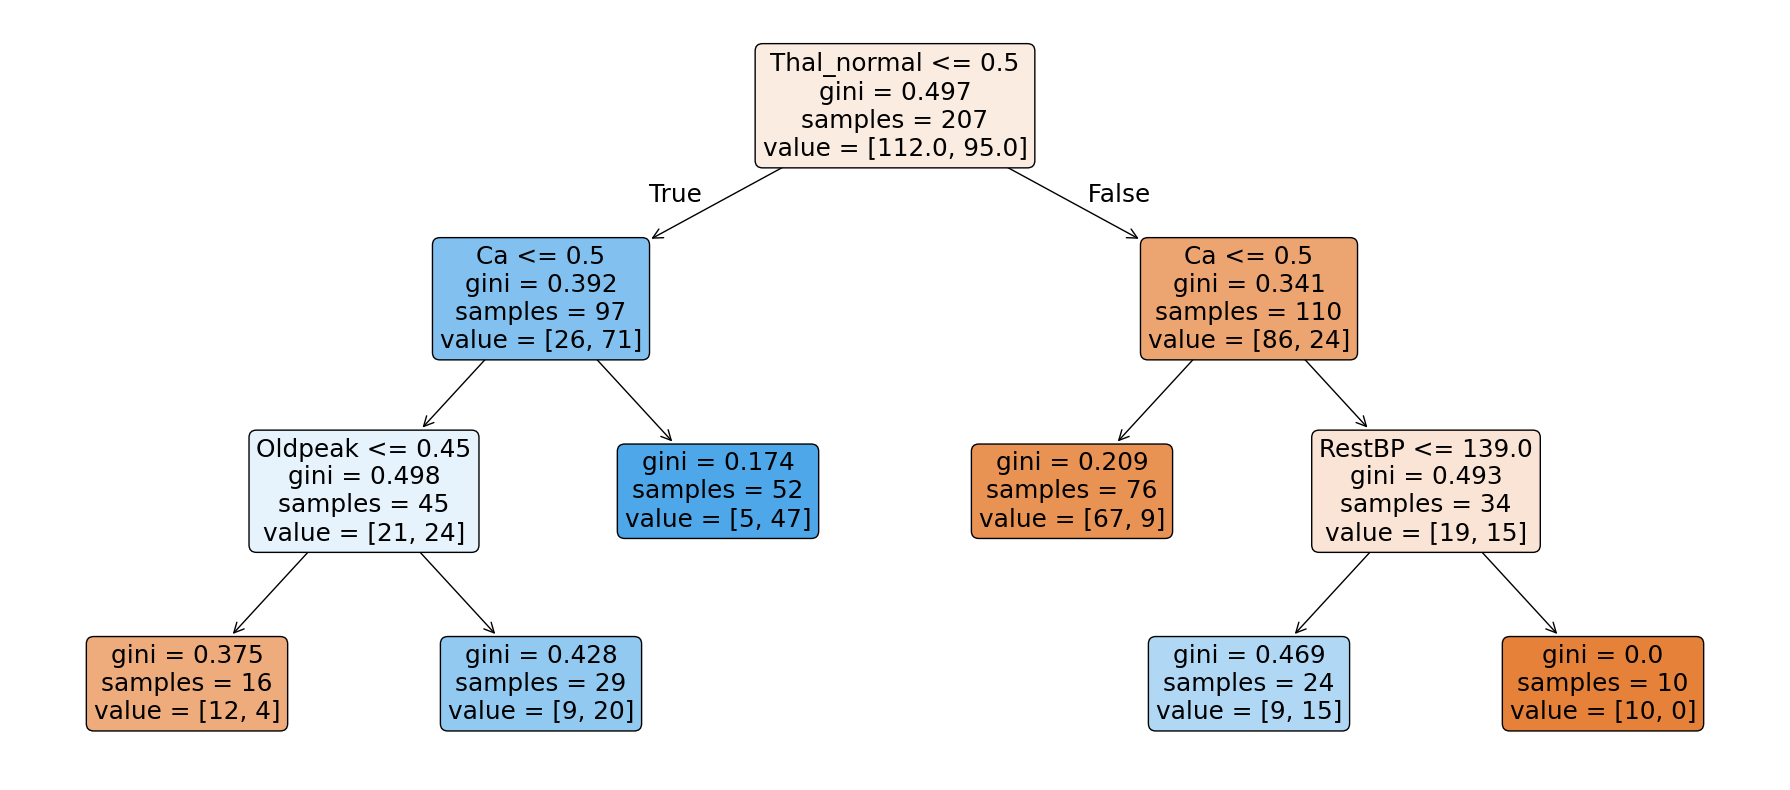

In [66]:
plt.figure(figsize=(18,8))

plot_tree(tree, feature_names=X.columns, filled=True, rounded=True)

plt.tight_layout()
plt.show()

In [67]:
y_pred = tree.predict(X_test)

print(confusion_matrix(y_test, y_pred))

[[36 12]
 [ 9 33]]


In [68]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.75      0.77        48
           1       0.73      0.79      0.76        42

    accuracy                           0.77        90
   macro avg       0.77      0.77      0.77        90
weighted avg       0.77      0.77      0.77        90



A classification tree recursively partitions the feature space into regions.

At each split, the algorithm selects:
- a variable (e.g. Cholesterol)
- a threshold (e.g. Chol < 245)

such that the resulting subsets are as **pure as possible**, meaning that observations in a node belong predominantly to a single class.

To quantify “purity”, we use **impurity measures**. The two most common are:

- Gini Impurity
- Entropy (Information Gain)

### Gini Impurity
The Gini index measures the probability of misclassifying a randomly chosen observation if we label it according to the class distribution in the node.

$$
G = 1 - \sum_{k=1}^{K} p_k^2
$$

where:
- $p_k$ = proportion of class $k$ in the node
- $K$ = number of classes

**Probability theory**:
> “How often would I be wrong if I randomly assigned labels according to the observed class proportions?”

- If a node contains only one class:
  - \(p = 1\)
  - Gini = 0 → **perfectly pure**

- If classes are evenly mixed:
  - e.g. 50% / 50%
  - Gini is maximised → **maximally impure**
  
### Entropy (Information Gain) 
Entropy measures the level of uncertainty (or disorder) in a node:

$$
H = - \sum_{k=1}^{K} p_k \log(p_k)
$$

where:
- $p_k$ = class proportion in the node

**Information theory**:

> It measures how “surprised” you are about the class of a randomly selected observation.

- If a node is pure:
  - no uncertainty
  - entropy = 0

- If classes are evenly mixed:
  - maximum uncertainty
  - entropy is maximised

In [69]:
depths = range(1, 15)

train_error = []
test_error = []

for depth in depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        criterion="gini",
        random_state=42
    )

    model.fit(X_train, y_train)

    # predictions
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    # error rates (NOT MSE)
    train_error.append(1 - accuracy_score(y_train, train_pred))
    test_error.append(1 - accuracy_score(y_test, test_pred))

results = pd.DataFrame({
    "Depth": depths,
    "Train_Error": train_error,
    "Test_Error": test_error
})

results["Generalisation_Gap"] = (
    results["Test_Error"] - results["Train_Error"]
)

results

,Depth,Train_Error,Test_Error,Generalisation_Gap
0,1,0.241546,0.222222,-0.019324
1,2,0.241546,0.222222,-0.019324
2,3,0.159420,0.233333,0.073913
3,4,0.101449,0.244444,0.142995
4,5,0.077295,0.233333,0.156039
5,6,0.053140,0.288889,0.235749
6,7,0.014493,0.288889,0.274396
7,8,0.000000,0.255556,0.255556
8,9,0.000000,0.255556,0.255556
9,10,0.000000,0.255556,0.255556


The generalisation gap measures:

$$
\text{Test Error} - \text{Train Error}
$$

As tree depth increases:

- training error decreases
- the gap widens
- variance increases

A large gap is often evidence of overfitting.

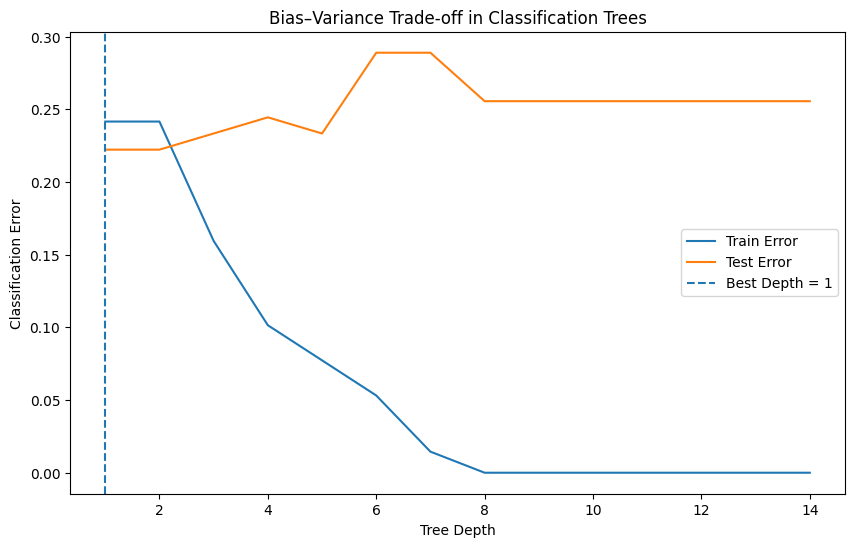

In [74]:
best_depth = results.loc[
    results["Test_Error"].idxmin(),
    "Depth"
]
best_depth

plt.figure(figsize=(10,6))

plt.plot(results["Depth"], results["Train_Error"], label="Train Error")
plt.plot(results["Depth"], results["Test_Error"], label="Test Error")
plt.axvline(best_depth, linestyle="--", label=f"Best Depth = {best_depth}")
plt.xlabel("Tree Depth")
plt.ylabel("Classification Error")
plt.title("Bias–Variance Trade-off in Classification Trees")
plt.legend()

plt.show()

In [75]:
depths = range(1, 15)

cv_mean_error = []
cv_std_error = []

for d in depths:

    model = DecisionTreeClassifier(
        max_depth=d,
        criterion="gini",
        random_state=42
    )

    # cross-validation accuracy (default: 5-fold)
    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="accuracy"
    )

    # convert accuracy → error
    error = 1 - scores

    cv_mean_error.append(error.mean())
    cv_std_error.append(error.std())

results_cv = pd.DataFrame({
    "Depth": depths,
    "CV_Error_Mean": cv_mean_error,
    "CV_Error_Std": cv_std_error
})

results_cv

,Depth,CV_Error_Mean,CV_Error_Std
0,1,0.236045,0.068629
1,2,0.256158,0.049568
2,3,0.222147,0.026098
3,4,0.232316,0.028975
4,5,0.272542,0.026993
5,6,0.275876,0.041913
6,7,0.289492,0.051380
7,8,0.312938,0.050693
8,9,0.299548,0.055253
9,10,0.299548,0.055253


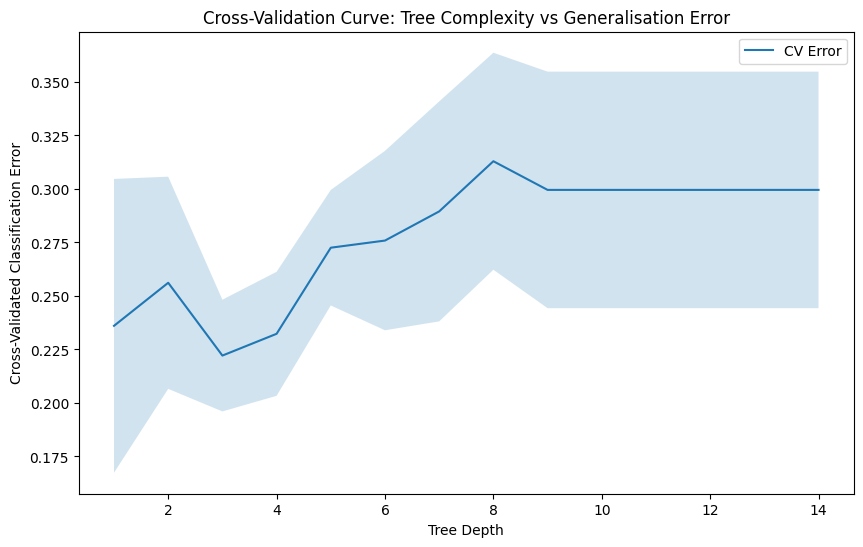

In [76]:
plt.figure(figsize=(10,6))

plt.plot(results_cv["Depth"], results_cv["CV_Error_Mean"], label="CV Error")

plt.fill_between(
    results_cv["Depth"],
    results_cv["CV_Error_Mean"] - results_cv["CV_Error_Std"],
    results_cv["CV_Error_Mean"] + results_cv["CV_Error_Std"],
    alpha=0.2
)

plt.xlabel("Tree Depth")
plt.ylabel("Cross-Validated Classification Error")
plt.title("Cross-Validation Curve: Tree Complexity vs Generalisation Error")
plt.legend()

plt.show()

### Cross-Validation Curve: Tree Depth vs. Generalization Error

While Cost-Complexity Pruning ($ccp\_alpha$) is a sophisticated way to trim a tree, **Tree Depth** is a more direct measure of complexity. This graph shows how the depth of the tree (number of layers) impacts its ability to predict accurately on unseen data.

#### 1. The Components
* **Solid Blue Line (Mean CV Error):** This is the average classification error across all cross-validation folds. Lower is better.
* **Shaded Area (Confidence Interval):** This represents the variance (standard deviation) of the error. A wider band means the model's performance was inconsistent across different data splits; a narrower band indicates a more stable model.

---

#### 2. Identifying the Zones
* **Underfitting (Left Side, Depth 1-2):** The error is relatively high because a tree with only 1 or 2 layers is too simple. It’s making "broad strokes" but missing the nuance in the heart disease data.
* **The Optimal Zone (Depth 3):** This is the **lowest point** on the curve (Error $\approx$ 0.22). A tree with a depth of 3 captures the most important patterns without getting lost in the noise.
* **Overfitting (Right Side, Depth 5+):** As the tree gets deeper, the error trends upward. Even though a deeper tree would have *lower* error on the training set, it performs *worse* on the cross-validation sets because it is memorizing specific outliers.

---

#### 3. Stability vs. Complexity
Notice that at **Depth 3**, not only is the mean error the lowest, but the **shaded variance band** is also relatively narrow. This suggests that a tree of depth 3 is a highly "stable" predictor—it performs consistently well regardless of which subset of data it is tested on.

**Conclusion:** Between this graph and the pruning analysis, there is a clear consensus: 
* **Pruning Alpha:** ~0.0164 
* **Max Depth:** 3 

Both methods point toward a tree with about 3 levels of decisions as the most reliable model for this dataset.

### Cost-Complexity Pruning (CCP) Path


In [77]:
# grow large tree
tree_full = DecisionTreeClassifier(
    random_state=42
)

path = tree_full.cost_complexity_pruning_path(X_train, y_train)

ccp_alphas = path.ccp_alphas
impurities = path.impurities

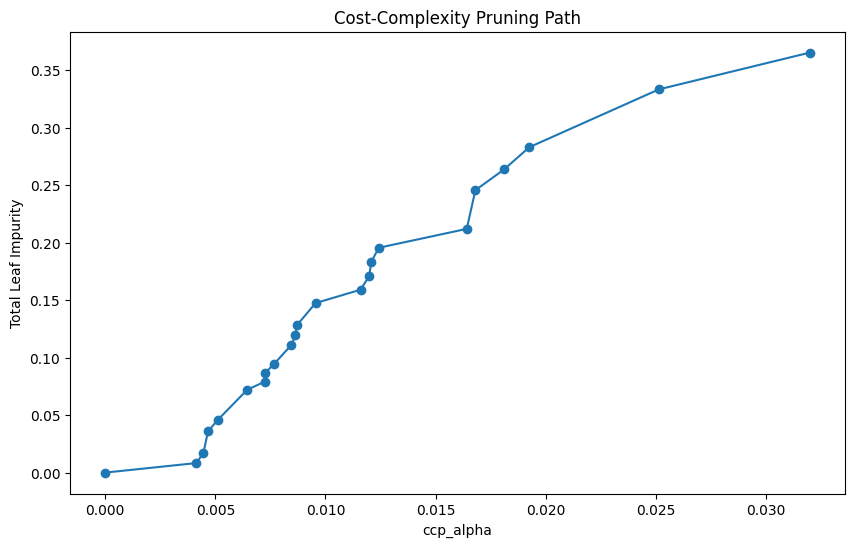

In [78]:
plt.figure(figsize=(10,6))

plt.plot(ccp_alphas[:-1], impurities[:-1], marker="o")

plt.xlabel("ccp_alpha")
plt.ylabel("Total Leaf Impurity")
plt.title("Cost-Complexity Pruning Path")

plt.show()

This plot visualizes the "pruning journey" of the decision tree. It shows how the **Total Leaf Impurity** increases as we increase the complexity penalty ($\alpha$).

* **X-Axis ($ccp\_alpha$):** The penalty parameter. A larger alpha forces the tree to be smaller by pruning branches that don't significantly reduce impurity.
* **Y-Axis (Total Leaf Impurity):** This measures how "mixed" the classes are in the leaf nodes. 
* **Key takeaway:** When $\alpha=0$, the impurity is $0$ because the tree is fully grown and perfectly fits the training data (overfitting). As $\alpha$ increases, we trade off training accuracy for a simpler model structure.

### Alpha Selection Table
This table provides the numerical backing for the Pruning Curve. It records the specific performance metrics for the first few candidate trees.

In [90]:
alpha_results = []

for alpha in ccp_alphas:

    model = DecisionTreeClassifier(
        random_state=42,
        ccp_alpha=alpha
    )

    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="accuracy"
    )

    alpha_results.append({
        "alpha": alpha,
        "cv_error_mean": 1 - scores.mean(),
        "cv_error_std": scores.std()
    })

alpha_results = pd.DataFrame(alpha_results)

alpha_results.head()

,alpha,cv_error_mean,cv_error_std
0,0.000000,0.299548,0.055253
1,0.004141,0.275932,0.043625
2,0.004459,0.272542,0.041850
3,0.004667,0.269209,0.037291
4,0.005127,0.265819,0.037725


* **CV Error Mean:** The average error rate across the 5 folds of cross-validation. Our goal was to minimize this value.
* **CV Error Std:** The standard deviation of the error. A lower standard deviation indicates that the model's performance is stable and consistent across different subsets of the data.

### The Pruning Curve (Cross-Validation)

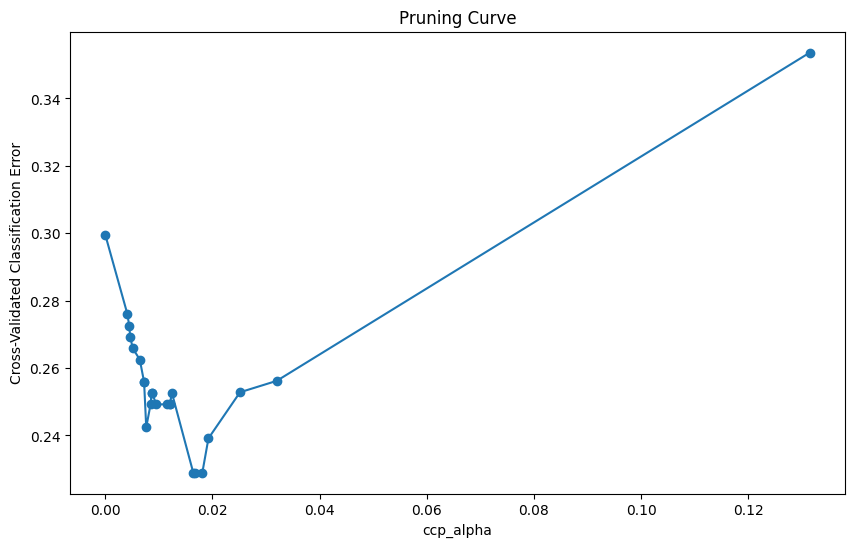

In [89]:
plt.figure(figsize=(10,6))

plt.plot(
    alpha_results["alpha"],
    alpha_results["cv_error_mean"],
    marker="o"
)

#plt.xscale("log") #you can represent it in Log_scale

plt.xlabel("ccp_alpha")
plt.ylabel("Cross-Validated Classification Error")

plt.title("Pruning Curve")

plt.show()

This curve is used to find the optimal balance between a tree that is too complex (overfitting) and a tree that is too simple (underfitting).

* **The Dip:** We are looking for the **lowest point** on this graph. This point represents the $ccp\_alpha$ that resulted in the lowest error when tested on unseen data during cross-validation.
* **Overfitting Zone (Left):** Low alpha values lead to higher error because the model is too sensitive to noise in the training set.
* **Underfitting Zone (Right):** High alpha values lead to higher error because the model is too simple to capture the actual patterns in the data.
* **Optimal Alpha:** Based on the plot, the error reaches its minimum around $ccp\_alpha \approx 0.016$, which is our "Sweet Spot."

In [84]:
best_row = alpha_results.loc[
    alpha_results["cv_error_mean"].idxmin()
]

best_alpha = best_row["alpha"]

best_alpha

np.float64(0.01641768859160162)

In [82]:
pruned_tree = DecisionTreeClassifier(
    random_state=42,
    ccp_alpha=best_alpha
)

pruned_tree.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=np.float64(0.01641768859160162),
                       random_state=42)

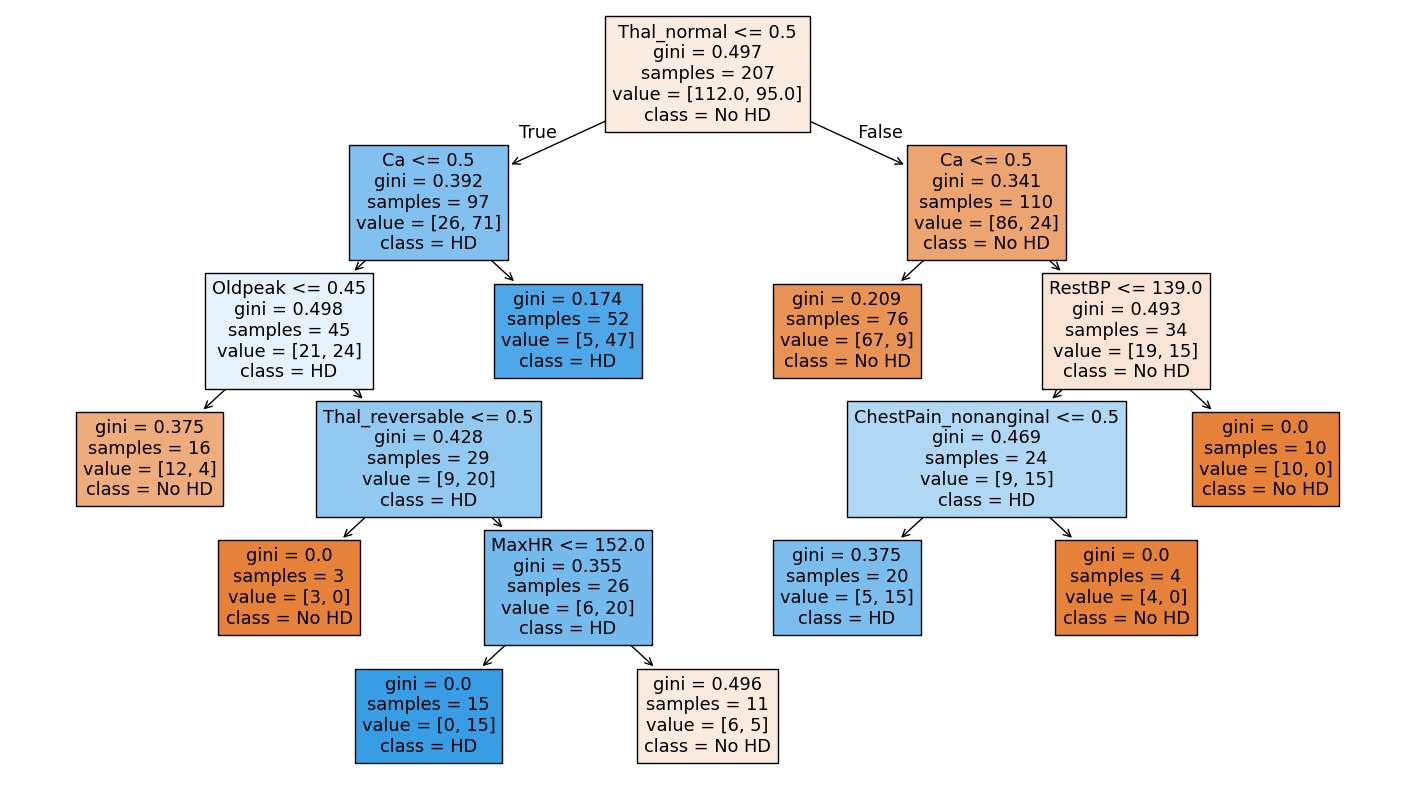

In [83]:
plt.figure(figsize=(18,10))

plot_tree(
    pruned_tree,
    feature_names=X.columns,
    class_names=["No HD", "HD"],
    filled=True
)

plt.show()

### Cost-Complexity Pruning & Root Node Logic

#### 1. The Root Node Split
The top-most node is the **Root Node**. It represents the entire training population ($n=207$) before any decisions are made. 

* **The Feature:** `Thal_normal <= 0.5`. This is the most "informative" feature in the dataset.
* **The Impurity (Gini):** At the start, the Gini impurity is **0.497**. Since a Gini of 0.5 indicates a perfect 50/50 split, our starting data is highly mixed (112 No HD vs. 95 HD).
* **The Decision:**
    * **True (Left):** Patients who do *not* have a normal Thalassemia test.
    * **False (Right):** Patients who *do* have a normal Thalassemia test.

---

#### 2. Information Gain
The algorithm chooses the split that maximizes **Information Gain**. This is calculated by measuring how much the Gini impurity drops after the split.

1. **Parent Gini:** $0.497$
2. **Left Child Gini:** $0.392$ (97 samples)
3. **Right Child Gini:** $0.341$ (110 samples)

**Weighted Impurity of Children:**
$$(\frac{97}{207} \times 0.392) + (\frac{110}{207} \times 0.341) \approx 0.365$$

**Information Gain:**
$$0.497 (\text{Parent}) - 0.365 (\text{Weighted Children}) = 0.132$$

The algorithm tested other features (like `Age` or `MaxHR`), but `Thal_normal` produced a higher gain than any other option, which is why it earned the top spot.

---

#### 3. Final Model Selection
Based on the **Pruning Curve**, we selected an optimal `ccp_alpha` of **0.0164**.

* **Why this alpha?** This value provided the lowest **Cross-Validated Classification Error** (~0.23). 
* **The Result:** The tree shown above is "Pruned." Branches that provided very low Information Gain (less than the penalty $\alpha$) were removed. 
* **Generalization:** This simplified tree is less likely to overfit to noise in the training data and will likely perform better on new, unseen patients.